In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [2]:
df = pd.read_csv("cleaned_health_data.csv")
df.head()

,Country,Year,Status,Life_expectancy,Adult_Mortality,infant_deaths,Alcohol,percentage_expenditure,Hepatitis_B,Measles,...,Polio,Total_expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness__1_19_years,thinness_5_9_years,Income_composition_of_resources,Schooling
0,Afghanistan,2015,0,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,0,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,0,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,0,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,0,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [3]:
df.describe()

,Year,Status,Life_expectancy,Adult_Mortality,infant_deaths,Alcohol,percentage_expenditure,Hepatitis_B,Measles,BMI,...,Polio,Total_expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness__1_19_years,thinness_5_9_years,Income_composition_of_resources,Schooling
count,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,...,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2.938000e+03,2938.000000,2938.000000,2938.000000,2938.000000
mean,2007.518720,0.174268,69.234717,164.725664,30.303948,4.546875,738.251295,83.022124,2419.592240,38.381178,...,82.617767,5.924098,82.393125,1.742103,6611.523863,1.023085e+07,4.821886,4.852144,0.630362,12.009837
std,4.613841,0.379405,9.509115,124.086215,117.926501,3.921946,1987.914858,22.996984,11467.272489,19.935375,...,23.367166,2.400770,23.655562,5.077785,13296.603449,5.402242e+07,4.397621,4.485854,0.205140,3.265139
min,2000.000000,0.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,...,3.000000,0.370000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,0.000000,63.200000,74.000000,0.000000,1.092500,4.685343,82.000000,0.000000,19.400000,...,78.000000,4.370000,78.000000,0.100000,580.486996,4.189172e+05,1.600000,1.600000,0.504250,10.300000
50%,2008.000000,0.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,...,93.000000,5.755000,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,0.000000,75.600000,227.000000,22.000000,7.390000,441.534144,96.000000,360.250000,56.100000,...,97.000000,7.330000,97.000000,0.800000,4779.405190,4.584371e+06,7.100000,7.200000,0.772000,14.100000
max,2015.000000,1.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,...,99.000000,17.600000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


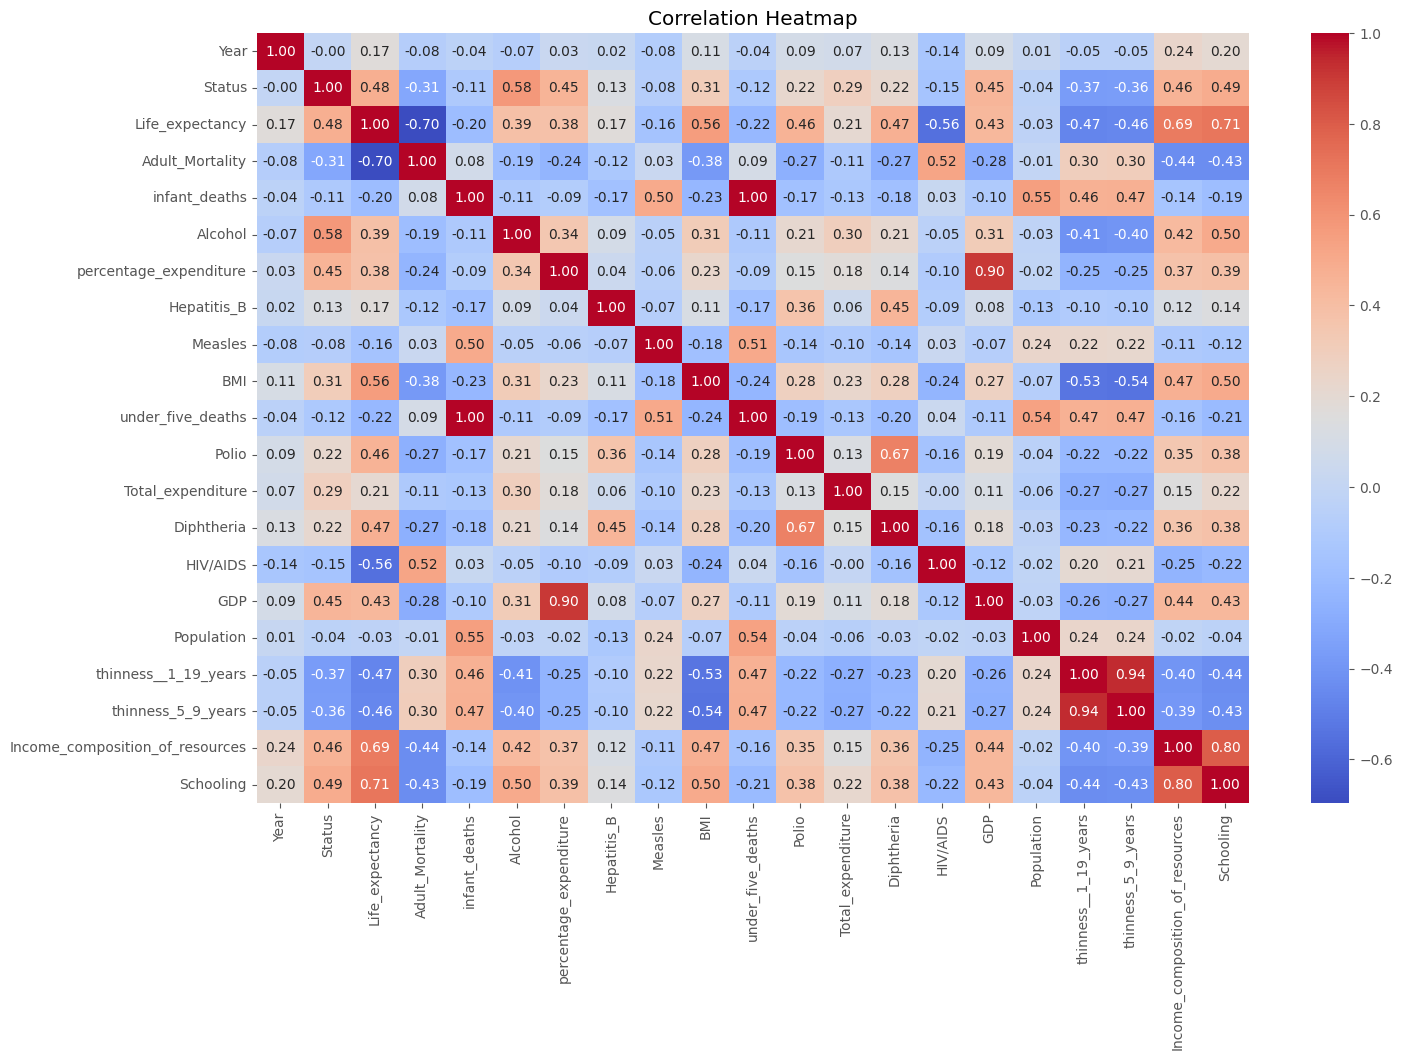

In [4]:
plt.figure(figsize=(16,10))
sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title("Correlation Heatmap")
plt.show()

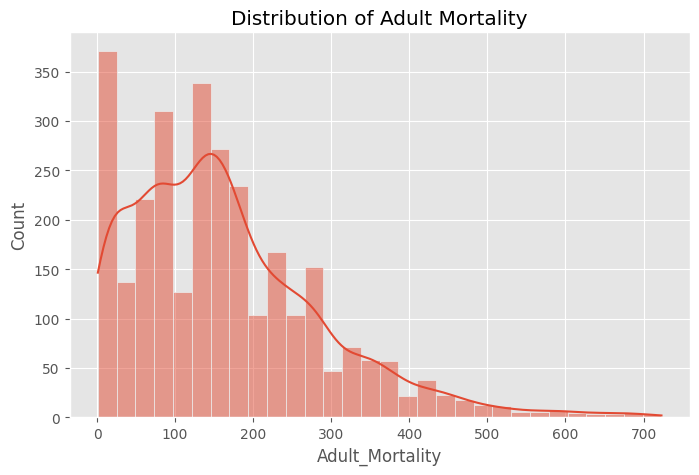

In [5]:
plt.figure(figsize=(8,5))
sns.histplot(df['Adult_Mortality'], kde=True, bins=30)
plt.title("Distribution of Adult Mortality")
plt.show()

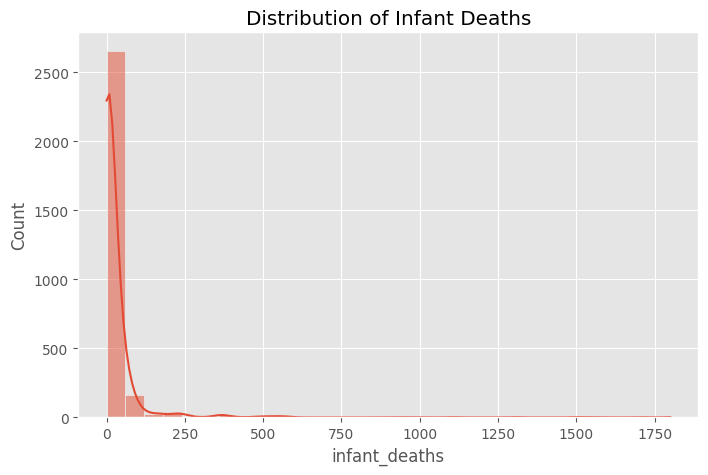

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df['infant_deaths'], kde=True, bins=30)
plt.title("Distribution of Infant Deaths")
plt.show()

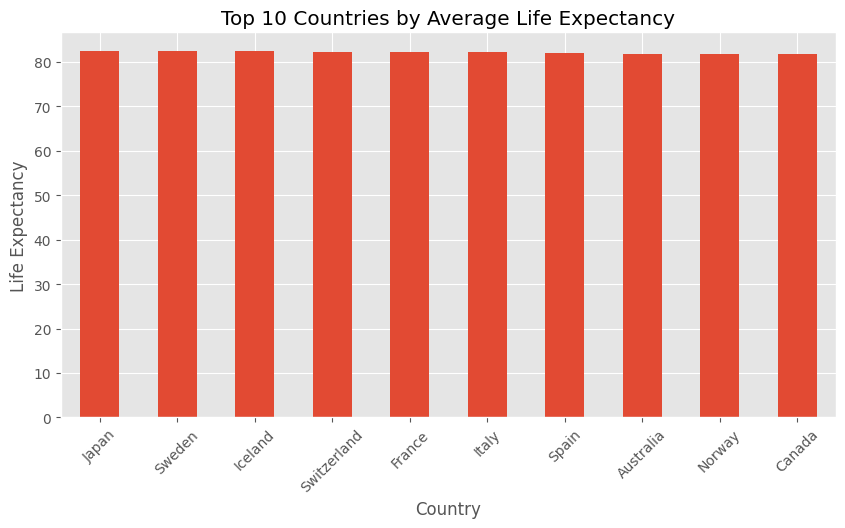

In [7]:
top_life = (
    df.groupby('Country')['Life_expectancy']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_life.plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Countries by Average Life Expectancy")
plt.ylabel("Life Expectancy")
plt.xticks(rotation=45)
plt.show()

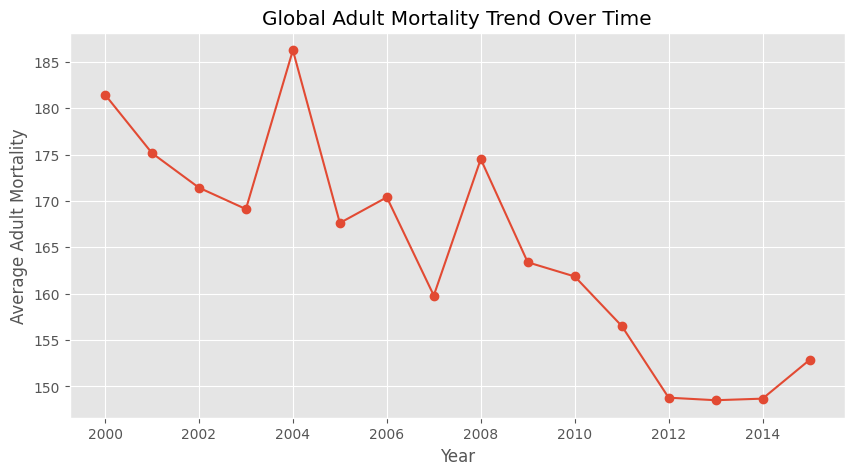

In [8]:
yearly_mortality = df.groupby('Year')['Adult_Mortality'].mean()

plt.figure(figsize=(10,5))
yearly_mortality.plot(marker='o')
plt.title("Global Adult Mortality Trend Over Time")
plt.ylabel("Average Adult Mortality")
plt.show()

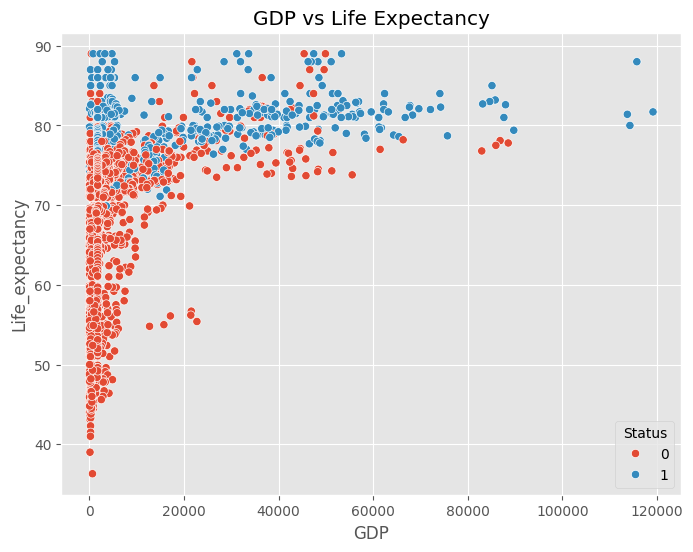

In [9]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='GDP',
    y='Life_expectancy',
    hue='Status'
)
plt.title("GDP vs Life Expectancy")
plt.show()

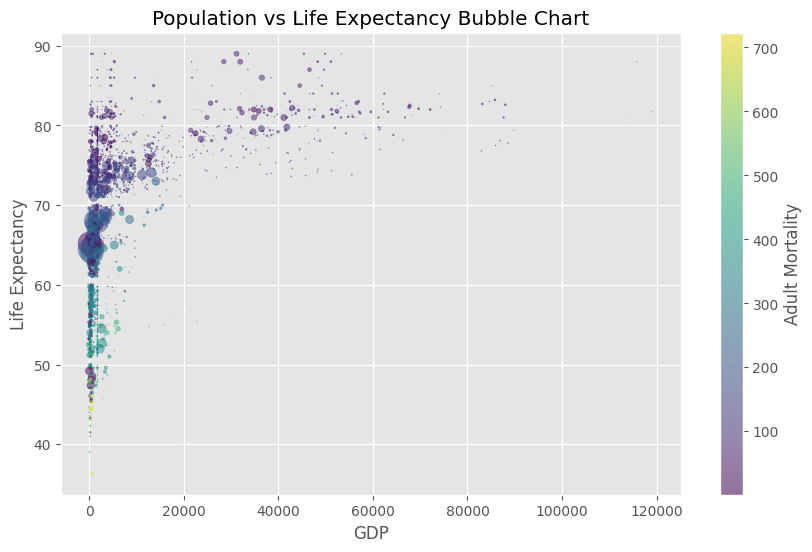

In [10]:
plt.figure(figsize=(10,6))

sizes = df['Population'] / df['Population'].max() * 300

plt.scatter(
    df['GDP'],
    df['Life_expectancy'],
    s=sizes,
    alpha=0.5,
    c=df['Adult_Mortality'],
    cmap='viridis'
)

plt.colorbar(label='Adult Mortality')
plt.xlabel("GDP")
plt.ylabel("Life Expectancy")
plt.title("Population vs Life Expectancy Bubble Chart")
plt.show()

In [11]:
df.to_csv("eda_ready_data.csv", index=False)